# Piezo Triangle Scan - Beam Position Analysis

Loads a CSV produced by `piezo_triangle_scan.py` (columns: sample, timestamp,
voltage_setpoint_V, voltage_readback_V, centroid_x_um, centroid_y_um,
peak_x_um, peak_y_um, peak_intensity_counts, total_power_mW) and plots:

- voltage and beam centroid vs. sample (time series)
- **X displacement vs. piezo voltage** (the mirror's transfer function),
  colored by sample order so any hysteresis between the rising and falling
  ramps of the triangle wave is visible
- a linear fit to estimate the X-axis sensitivity in um/V


In [30]:
import glob
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline

DATA_DIR = "."

# pick the most recent scan CSV by default; override CSV_PATH to load a specific file
csv_files = sorted(glob.glob(os.path.join(DATA_DIR, "piezo_scan_*.csv")))
CSV_PATH = csv_files[-2] if csv_files else None
# CSV_PATH = "piezo_scan_20260625_164729.csv"
print("Available scans:", [os.path.basename(f) for f in csv_files])
print("Loading:", CSV_PATH)

Available scans: ['piezo_scan_20260625_153938.csv', 'piezo_scan_20260625_160026.csv', 'piezo_scan_20260625_164729.csv', 'piezo_scan_20260701_151258_min8.0_max12.0_axisX.csv', 'piezo_scan_20260701_151843_min0.0_max150.0.csv', 'piezo_scan_20260701_152008_min8.0_max12.0.csv', 'piezo_scan_20260701_154619_min8.0_max12.0.csv', 'piezo_scan_20260701_154947_min8.0_max12.0.csv', 'piezo_scan_20260701_155451_min0.0_max150.0.csv', 'piezo_scan_20260701_155840_min0.0_max20.0.csv', 'piezo_scan_20260701_160930_min0.0_max20.0.csv']
Loading: .\piezo_scan_20260701_155840_min0.0_max20.0.csv


In [31]:
df = pd.read_csv(CSV_PATH, parse_dates=["timestamp"])
df.head()

,sample,timestamp,voltage_setpoint_V,voltage_readback_V,centroid_x_um,centroid_y_um,gaussfit_center_x_um,gaussfit_center_y_um,gaussfit_rating_x,gaussfit_rating_y,peak_intensity_counts,total_power_mW
0,0,2026-07-01 15:55:18.539697,0.0,0.00,-590.408433,44.349260,-1683.236577,357.703746,0.919245,0.921127,7.0,0.000008
1,1,2026-07-01 15:55:19.771728,0.5,0.00,-585.905165,43.379634,-1672.320512,350.548278,0.911502,0.918745,7.0,0.000008
2,2,2026-07-01 15:55:20.602141,1.0,0.57,-590.760774,42.765499,-1687.624695,359.035161,0.912919,0.916597,7.0,0.000008
3,3,2026-07-01 15:55:21.432332,1.5,1.55,-584.974906,44.533895,-1696.693039,362.933348,0.912415,0.916784,7.0,0.000008
4,4,2026-07-01 15:55:22.252817,2.0,1.55,-589.683280,41.946651,-1688.510074,350.521114,0.915251,0.915712,7.0,0.000008


## Voltage and beam centroid vs. sample

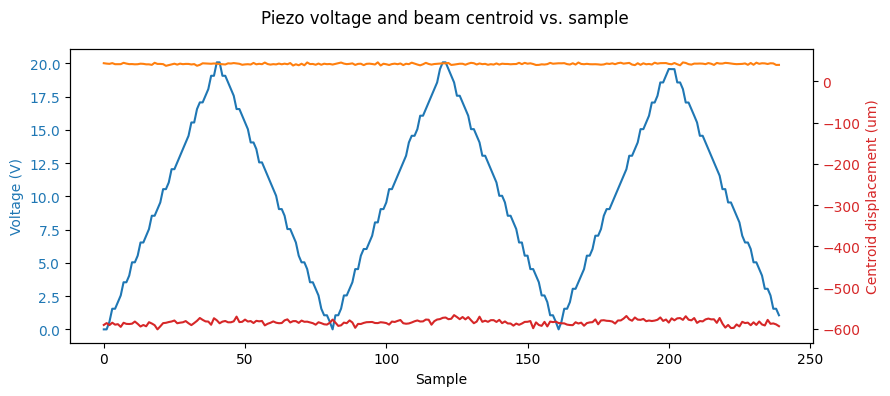

In [32]:
fig, ax_v = plt.subplots(figsize=(9, 4))
ax_v.plot(df["sample"], df["voltage_readback_V"], color="tab:blue", label="Piezo voltage (readback)")
ax_v.set_xlabel("Sample")
ax_v.set_ylabel("Voltage (V)", color="tab:blue")
ax_v.tick_params(axis="y", labelcolor="tab:blue")

ax_p = ax_v.twinx()
ax_p.plot(df["sample"], df["centroid_x_um"], color="tab:red", label="Centroid X")
ax_p.plot(df["sample"], df["centroid_y_um"], color="tab:orange", label="Centroid Y")
ax_p.set_ylabel("Centroid displacement (um)", color="tab:red")
ax_p.tick_params(axis="y", labelcolor="tab:red")

fig.suptitle("Piezo voltage and beam centroid vs. sample")
fig.tight_layout()
plt.show()

## X displacement vs. voltage

Each point is colored by sample index (time order), so the rising and
falling legs of the triangle wave are distinguishable - a gap between
the two colors at the same voltage indicates piezo hysteresis.

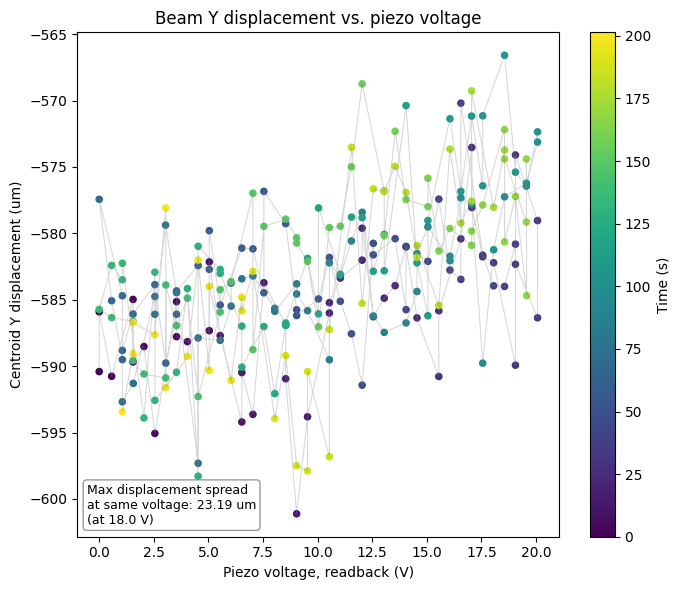

Max displacement spread at the same voltage: 23.188 um, at setpoint 18.00 V


In [33]:
elapsed_s = (df["timestamp"] - df["timestamp"].iloc[0]).dt.total_seconds()

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(df["voltage_readback_V"], df["centroid_x_um"],
                 c=elapsed_s, cmap="viridis", s=20)
ax.plot(df["voltage_readback_V"], df["centroid_x_um"], "-", color="gray", alpha=0.3, linewidth=0.8)

ax.set_xlabel("Piezo voltage, readback (V)")
ax.set_ylabel("Centroid Y displacement (um)")
ax.set_title("Beam Y displacement vs. piezo voltage")

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Time (s)")

# max spread in X displacement among samples that share the same voltage setpoint --
# this is the hysteresis gap between the rising and falling legs of the triangle wave
spread_by_voltage = df.groupby("voltage_setpoint_V")["centroid_x_um"].agg(lambda s: s.max() - s.min())
max_spread = spread_by_voltage.max()
max_spread_voltage = spread_by_voltage.idxmax()

ax.annotate(
    f"Max displacement spread\nat same voltage: {max_spread:.2f} um\n(at {max_spread_voltage:.1f} V)",
    xy=(0.02, 0.02), xycoords="axes fraction", va="bottom", ha="left",
    fontsize=9, bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.8),
)

fig.tight_layout()
plt.show()

print(f"Max displacement spread at the same voltage: {max_spread:.3f} um, at setpoint {max_spread_voltage:.2f} V")

## Linear fit: X-axis sensitivity (um/V)

X sensitivity: 0.569 um/V
Intercept: -589.126 um


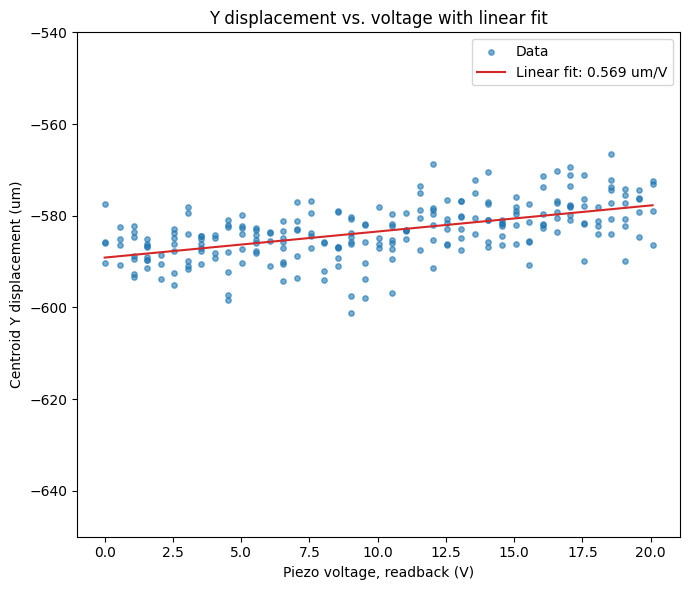

In [34]:
slope, intercept = np.polyfit(df["voltage_readback_V"], df["centroid_x_um"], 1)
print(f"X sensitivity: {slope:.3f} um/V")
print(f"Intercept: {intercept:.3f} um")

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(df["voltage_readback_V"], df["centroid_x_um"], s=15, alpha=0.6, label="Data")

v_fit = np.linspace(df["voltage_readback_V"].min(), df["voltage_readback_V"].max(), 200)
ax.plot(v_fit, slope * v_fit + intercept, color="tab:red",
        label=f"Linear fit: {slope:.3f} um/V")

ax.set_ylim(-650, -540)
ax.set_xlabel("Piezo voltage, readback (V)")
ax.set_ylabel("Centroid Y displacement (um)")
ax.set_title("Y displacement vs. voltage with linear fit")
ax.legend()
fig.tight_layout()
plt.show()